### All days of the challange:

* [Day 1: Handling missing values](https://www.kaggle.com/rtatman/data-cleaning-challenge-handling-missing-values)
* [Day 2: Scaling and normalization](https://www.kaggle.com/rtatman/data-cleaning-challenge-scale-and-normalize-data)
* [Day 3: Parsing dates](https://www.kaggle.com/rtatman/data-cleaning-challenge-parsing-dates/)
* [Day 4: Character encodings](https://www.kaggle.com/rtatman/data-cleaning-challenge-character-encodings/)
* [Day 5: Inconsistent Data Entry](https://www.kaggle.com/rtatman/data-cleaning-challenge-inconsistent-data-entry/)
___
Welcome to day 3 of the 5-Day Data Challenge! Today, we're going to work with dates. To get started, click the blue "Fork Notebook" button in the upper, right hand corner. This will create a private copy of this notebook that you can edit and play with. Once you're finished with the exercises, you can choose to make your notebook public to share with others. :)

> **Your turn!** As we work through this notebook, you'll see some notebook cells (a block of either code or text) that has "Your Turn!" written in it. These are exercises for you to do to help cement your understanding of the concepts we're talking about. Once you've written the code to answer a specific question, you can run the code by clicking inside the cell (box with code in it) with the code you want to run and then hit CTRL + ENTER (CMD + ENTER on a Mac). You can also click in a cell and then click on the right "play" arrow to the left of the code. If you want to run all the code in your notebook, you can use the double, "fast forward" arrows at the bottom of the notebook editor.

Here's what we're going to do today:

* [Get our environment set up](#Get-our-environment-set-up)
* [Check the data type of our date column](#Check-the-data-type-of-our-date-column)
* [Convert our date columns to datetime](#Convert-our-date-columns-to-datetime)
* [Select just the day of the month from our column](#Select-just-the-day-of-the-month-from-our-column)
* [Plot the day of the month to check the date parsing](#Plot-the-day-of-the-month-to-the-date-parsing)

Let's get started!

# Thiết lập môi trường làm việc
________

Việc đầu tiên cần làm là tải các thư viện và bộ dữ liệu mà chúng ta sẽ sử dụng. Hôm nay, chúng ta sẽ làm việc với hai bộ dữ liệu: một bộ chứa thông tin về các trận động đất xảy ra từ năm 1965 đến 2016, và bộ còn lại chứa thông tin về các vụ sạt lở đất xảy ra từ năm 2007 đến 2016.

> **Quan trọng!** Hãy đảm bảo bạn tự chạy ô mã lệnh này, nếu không phần còn lại của mã nguồn sẽ không hoạt động!

In [1]:
# modules we'll use
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# read in our data
earthquakes = pd.read_csv("../input/earthquake-database/database.csv")
landslides = pd.read_csv("../input/landslide-events/catalog.csv")
volcanos = pd.read_csv("../input/volcanic-eruptions/database.csv")

# set seed for reproducibility
np.random.seed(0)

Bây giờ chúng ta đã sẵn sàng xem xét một số mốc thời gian! (Nếu muốn, bạn có thể tận dụng cơ hội này để xem qua một số dữ liệu.)

# Kiểm tra kiểu dữ liệu của cột ngày tháng
___

Trong phần này của thử thách, tôi sẽ làm việc với cột `date` từ dataframe `landslides`. Việc đầu tiên tôi sẽ làm là xem qua vài dòng đầu tiên để đảm bảo rằng dữ liệu trong cột này thực sự trông giống như các giá trị ngày tháng.

In [2]:
# print the first few rows of the date column
print(landslides['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object


Đúng vậy, đó là các giá trị ngày tháng! Tuy nhiên, việc tôi—một con người—có thể nhận ra đó là ngày tháng không có nghĩa là Python cũng hiểu chúng là ngày tháng. Hãy để ý phần cuối kết quả của hàm `head()`: bạn sẽ thấy kiểu dữ liệu (dtype) của cột này được hiển thị là "object".

> Pandas sử dụng kiểu dữ liệu "object" để lưu trữ nhiều loại dữ liệu khác nhau, nhưng thông thường, khi thấy một cột có kiểu "object", thì cột đó thường chứa các chuỗi văn bản (strings).

Nếu xem tài liệu về kiểu dữ liệu của pandas tại [đây](http://pandas.pydata.org/pandas-docs/stable/basics.html#dtypes), bạn sẽ thấy còn có một kiểu dữ liệu cụ thể là `datetime64`. Vì cột của chúng ta đang có kiểu là `object` thay vì `datetime64`, nên ta có thể kết luận rằng Python chưa nhận diện được cột này chứa dữ liệu ngày tháng.

Chúng ta cũng có thể chỉ kiểm tra kiểu dữ liệu của cột mà không cần in ra vài dòng đầu tiên nếu muốn:

In [3]:
# check the data type of our date column
landslides['date'].dtype

dtype('O')

Bạn có thể cần tham khảo [tài liệu của numpy](https://docs.scipy.org/doc/numpy-1.12.0/reference/generated/numpy.dtype.kind.html#numpy.dtype.kind) để đối chiếu mã ký tự với kiểu dữ liệu (dtype) của đối tượng. "O" là mã đại diện cho "object", vì vậy ta thấy rằng cả hai phương thức này đều cung cấp cùng một thông tin.

In [8]:
# Your turn! Check the data type of the Date column in the earthquakes dataframe
# (note the capital 'D' in date!)
print(earthquakes['Date'].head())
earthquakes['Date'].dtype

0    01/02/1965
1    01/04/1965
2    01/05/1965
3    01/08/1965
4    01/09/1965
Name: Date, dtype: object


dtype('O')

# Chuyển đổi các cột ngày tháng sang định dạng datetime
___

Giờ đây khi đã biết cột ngày tháng của mình chưa được hệ thống nhận diện đúng là dữ liệu kiểu ngày tháng, chúng ta cần chuyển đổi nó để nó được nhận diện chính xác. Quá trình này được gọi là "phân tích cú pháp ngày tháng" (parsing dates), vì chúng ta lấy một chuỗi văn bản và xác định các thành phần cấu tạo nên nó.

Chúng ta có thể chỉ định định dạng ngày tháng cho pandas bằng cách sử dụng các mã định dạng được gọi là "chỉ thị strftime" (bạn có thể tìm hiểu thêm thông tin tại [liên kết này](http://strftime.org/)). Nguyên tắc cơ bản là bạn cần xác định vị trí của các thành phần ngày tháng và các ký tự phân cách giữa chúng. Có [rất nhiều thành phần ngày tháng khác nhau](http://strftime.org/), nhưng phổ biến nhất là `%d` cho ngày, `%m` cho tháng, `%y` cho năm có hai chữ số và `%Y` cho năm có bốn chữ số.

Một số ví dụ:

* 1/17/07 có định dạng là "%m/%d/%y"
* 17-1-2007 có định dạng là "%d-%m-%Y"

Nhìn lại phần đầu của cột `date` trong tập dữ liệu về sạt lở đất (landslides), ta thấy nó có định dạng "tháng/ngày/năm có hai chữ số", vì vậy chúng ta có thể sử dụng cú pháp tương tự như ví dụ đầu tiên để phân tích dữ liệu ngày tháng này:

In [5]:
# create a new column, date_parsed, with the parsed dates
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format = "%m/%d/%y")

Bây giờ, khi kiểm tra vài dòng đầu tiên của cột mới, tôi thấy kiểu dữ liệu (dtype) là `datetime64`. Tôi cũng nhận thấy các ngày tháng đã được sắp xếp lại đôi chút để khớp với thứ tự mặc định của các đối tượng datetime (năm-tháng-ngày).

In [6]:
# print the first few rows
landslides['date_parsed'].head()

0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[ns]

Giờ đây khi các giá trị ngày tháng đã được phân tích cú pháp chính xác, chúng ta có thể thao tác với chúng theo những cách hữu ích.

___
* **Làm thế nào nếu tôi gặp lỗi do có nhiều định dạng ngày tháng khác nhau?** Mặc dù ở đây chúng ta đang chỉ định cụ thể định dạng ngày tháng, nhưng đôi khi bạn sẽ gặp lỗi nếu một cột dữ liệu chứa nhiều định dạng ngày tháng khác nhau. Trong trường hợp đó, bạn có thể yêu cầu pandas tự động nhận diện (suy luận) định dạng ngày tháng phù hợp. Bạn có thể thực hiện việc này như sau:

`landslides['date_parsed'] = pd.to_datetime(landslides['Date'], infer_datetime_format=True)`

* **Tại sao không phải lúc nào cũng sử dụng `infer_datetime_format = True`?** Có hai lý do chính khiến ta không nên luôn để pandas tự đoán định dạng thời gian. Thứ nhất, pandas không phải lúc nào cũng xác định đúng định dạng ngày tháng, đặc biệt là khi dữ liệu được nhập theo những cách không theo quy chuẩn thông thường. Thứ hai, quá trình này chậm hơn nhiều so với việc chỉ định chính xác định dạng của ngày tháng.
____

In [16]:
# Your turn! Create a new column, date_parsed, in the earthquakes
# dataset that has correctly parsed dates in it. (Don't forget to 
# double-check that the dtype is correct!)
earthquakes['Date_parsed'] = pd.to_datetime(earthquakes['Date'], infer_datetime_format=True)
earthquakes['Date_parsed'].head()

0   1965-01-02
1   1965-01-04
2   1965-01-05
3   1965-01-08
4   1965-01-09
Name: Date_parsed, dtype: datetime64[ns]

# Chỉ chọn ngày trong tháng từ cột dữ liệu của chúng ta
___

"Được rồi, Rachael," có thể bạn sẽ nói vào lúc này, "Việc loay hoay với các kiểu dữ liệu này cũng ổn đấy, nhưng rốt cuộc thì *mục đích* là gì?" Để trả lời câu hỏi của bạn, hãy thử trích xuất thông tin về ngày xảy ra sạt lở đất từ ​​cột "date" (ngày tháng) ban đầu—cột vốn đang có kiểu dữ liệu là "object":

In [17]:
# try to get the day of the month from the date column
day_of_month_landslides = landslides['date'].dt.day

AttributeError: Can only use .dt accessor with datetimelike values

Chúng ta gặp lỗi rồi! Điểm quan trọng cần lưu ý ở đây là dòng thông báo cuối cùng: `AttributeError: Can only use .dt accessor with datetimelike values`. Lỗi này xảy ra vì hàm `dt.day()` không thể xử lý cột có kiểu dữ liệu (dtype) là "object". Mặc dù dataframe của chúng ta có chứa dữ liệu ngày tháng, nhưng do chưa được chuyển đổi định dạng (parsed), nên ta không thể thao tác với chúng một cách hiệu quả.

May mắn thay, chúng ta có một cột đã được chuyển đổi định dạng từ trước, cho phép ta trích xuất thông tin ngày trong tháng mà không gặp trở ngại nào:

In [18]:
# get the day of the month from the date_parsed column
day_of_month_landslides = landslides['date_parsed'].dt.day

In [23]:
# Your turn! get the day of the month from the date_parsed column
day_of_month_earthquakes = earthquakes['Date_parsed'].dt.day
print(day_of_month_earthquakes.head())

0    2
1    4
2    5
3    8
4    9
Name: Date_parsed, dtype: int64


# Vẽ biểu đồ ngày trong tháng để kiểm tra quá trình phân tích dữ liệu ngày tháng
___

Một trong những rủi ro lớn nhất khi phân tích dữ liệu ngày tháng là nhầm lẫn giữa tháng và ngày. Mặc dù hàm `to_datetime()` cung cấp các thông báo lỗi rất hữu ích, nhưng việc kiểm tra lại xem các giá trị ngày trong tháng đã trích xuất có hợp lý hay không vẫn là điều cần thiết.

Để thực hiện việc này, chúng ta hãy vẽ biểu đồ tần suất (histogram) của các ngày trong tháng. Chúng ta kỳ vọng các giá trị sẽ nằm trong khoảng từ 1 đến 31; đồng thời, do không có lý do gì để cho rằng các vụ sạt lở đất xảy ra thường xuyên hơn vào một số ngày cụ thể trong tháng so với những ngày khác, nên phân bố dữ liệu sẽ tương đối đều (ngoại trừ một sự sụt giảm ở ngày 31 vì không phải tháng nào cũng có 31 ngày). Hãy cùng xem liệu thực tế có đúng như vậy không:

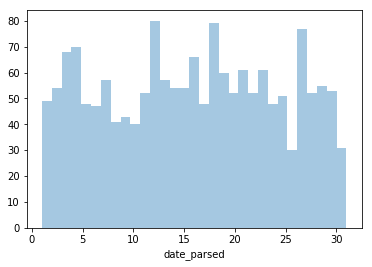

In [24]:
# remove na's
day_of_month_landslides = day_of_month_landslides.dropna()

# plot the day of the month
sns.distplot(day_of_month_landslides, kde=False, bins=31)

Đúng vậy, có vẻ như chúng ta đã xử lý các mốc thời gian một cách chính xác và biểu đồ này rất hợp lý. Bạn thử kiểm tra lại các mốc thời gian mà bạn đã xử lý lúc trước xem sao?

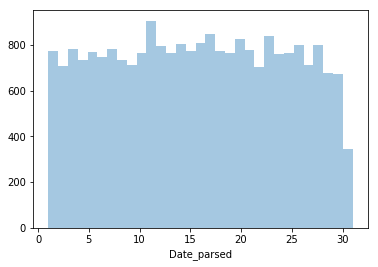

In [26]:
# Your turn! Plot the days of the month from your
# earthquake dataset and make sure they make sense.
day_of_month_earthquakes = day_of_month_earthquakes.dropna()
sns.distplot(day_of_month_earthquakes, kde = False, bins = 31)

Đó là tất cả nội dung cho hôm nay! Nếu có bất kỳ câu hỏi nào, hãy đăng chúng vào phần bình luận bên dưới hoặc [trên diễn đàn](https://www.kaggle.com/questions-and-answers).

Hãy nhớ rằng notebook của bạn mặc định ở chế độ riêng tư; để chia sẻ với người khác hoặc nhờ hỗ trợ, bạn cần chuyển nó sang chế độ công khai (public). Trước tiên, bạn cần lưu lại một phiên bản notebook chứa các nội dung đang thực hiện bằng cách nhấn nút "Commit & Run". (Công việc của bạn được lưu tự động, nhưng việc tạo phiên bản giúp bạn xem lại trạng thái dữ liệu tại thời điểm lưu; đồng thời cho phép chia sẻ một bản notebook đã được biên dịch hoàn chỉnh thay vì chỉ là mã nguồn thô.) Sau khi notebook chạy xong, hãy vào thẻ Settings (Cài đặt) ở bảng điều khiển bên trái (bạn có thể cần mở rộng bảng này bằng cách nhấn nút [<] nằm cạnh nút "Commit & Run") và chuyển tùy chọn "Visibility" (Hiển thị) sang chế độ "Public" (Công khai).

# Luyện tập thêm!
___

Nếu bạn quan tâm đến việc vẽ biểu đồ chuỗi thời gian (time series), hãy [xem bài hướng dẫn này](https://www.kaggle.com/residentmario/time-series-plotting-optional).

Bạn cũng có thể thử truyền các cột chứa dữ liệu ngày tháng vào tham số `parse_dates` của hàm `read_csv`. (Bạn có thể xem tài liệu hướng dẫn [tại đây](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html).) Lưu ý rằng phương pháp này có thể chạy khá chậm, nhưng tùy vào nhu cầu thực tế, đôi khi nó lại rất hữu ích.

Để thử thách bản thân hơn nữa, bạn có thể thử xử lý cột `Last Known Eruption` trong dataframe `volcanos`. Cột này chứa hỗn hợp các giá trị văn bản (như "Unknown") và các mốc năm thuộc cả thời kỳ trước Công nguyên (BCE hay BC) lẫn Công nguyên (CE hay AD).

In [48]:
volcanos['Last Known Eruption'].sample(5)

1222    320 BCE
1434    1961 CE
704     1936 CE
1142    Unknown
127     Unknown
Name: Last Known Eruption, dtype: object

In [49]:
import pandas as pd
import numpy as np

# 1. Trích xuất số năm và đơn vị (CE/BCE)
extracted = volcanos['Last Known Eruption'].str.extract(r'(\d+)\s*(CE|BCE)')

# 2. Chuyển cột năm thành kiểu Int64
years = pd.to_numeric(extracted[0], errors='coerce')

# 3. Đổi dấu âm cho các năm BCE
is_bce = extracted[1] == 'BCE'
years = np.where(is_bce, -years, years)

# 4. Gán kết quả lại dataframe
volcanos['Last_Known_Eruption_parsed'] = years

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:5: FutureWarning: currently extract(expand=None) means expand=False (return Index/Series/DataFrame) but in a future version of pandas this will be changed to expand=True (return DataFrame)
  """


In [50]:
# Xem thử các giá trị đã chuyển đổi thành công
print(volcanos[['Last Known Eruption', 'Last_Known_Eruption_parsed']].sample(10))

# Kiểm tra kiểu dữ liệu (dtype phải là float64 hoặc float/Int64)
print(volcanos['Last_Known_Eruption_parsed'].dtype)

     Last Known Eruption  Last_Known_Eruption_parsed
526              Unknown                         NaN
84               Unknown                         NaN
954              2006 CE                      2006.0
250              Unknown                         NaN
1459             1971 CE                      1971.0
1440             Unknown                         NaN
551              1854 CE                      1854.0
765              300 BCE                      -300.0
418              Unknown                         NaN
1119             Unknown                         NaN
float64
